# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "ccl4"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[102.768 103.4788 104.1896 ... 109.402 109.937 109.937] [102.768 103.4788 104.1896 ... 109.22009999999999 109.937 109.937] [102.768 103.4788 104.28766666666667 ... 109.22009999999999 109.937 109.937] [102.768 103.4849 104.2018 ... 109.2201 109.937 109.937] [102.768 103.4788 104.28766666666667 ... 109.22009999999999 109.937 109.937] [102.768 103.4788 104.18960000000001 ... 109.2201 109.937 109.937]] [[103.21 103.8428 104.47559999999999 ... 109.583 110.219 110.219] [103.21 103.8428 104.47559999999999 ... 109.51809999999999 110.219 110.219] [103.21 103.8428 104.5875 ... 109.51809999999999 110.219 110.219] [103.21 103.91089999999998 104.6118 ... 109.51809999999999 110.219 110.219] [103.21 103.8428 104.58749999999999 ... 109.5181 110.219 110.219] [103.21 103.8428 104.4756 ... 109.5181 110.219 110.219]] [[102.991 103.6414 104.2918 ... 110.13966666666667 111.004 111.004] [102.991 103.6414 104.2918 ... 110.20270000000001 111.004 111.004] [102.991 103.6414 104.43633333333334 ... 110.2027 111.004 111.004] [102.991 103.7923 104.59360000000001 ... 110.20270000000002 111.004 111.004] [102.991 103.6414 104.43633333333332 ... 110.2027 111.004 111.004] [102.991 103.6414 104.2918 ... 110.20270000000001 111.004 111.004]] ... [[72.532 72.4947 72.5015 ... 74.0975 74.005 73.792] [72.532 72.47999999999999 72.69857142857143 ... 73.93733333333334 73.86466666666668 73.792] [72.532 72.64581818181817 72.92545454545454 ... 73.97 73.659 73.792] [72.532 72.7575 72.983 ... 74.37 73.7455 73.792] [72.532 72.52409999999999 72.64025 ... 74.27916666666667 73.832 73.792] [72.532 72.5094 72.5162 ... 74.18833333333333 73.9185 73.792]] [[72.472 72.45 72.42800000000001 ... 73.9075 73.958 73.715] [72.472 72.44999999999999 72.53927272727273 ... 73.86366666666667 73.78933333333333 73.715] [72.472 72.50563636363637 72.72014285714286 ... 73.708 73.574 73.715] [72.472 72.58657142857142 72.70114285714286 ... 73.462 73.66999999999999 73.715] [72.472 72.45 72.49628571428572 ... 73.558 73.76599999999999 73.715] [72.472 72.45 72.428 ... 73.654 73.86200000000001 73.715]] [[72.391 72.36966666666667 72.34833333333333 ... 73.923 74.068 73.637] [72.391 72.36966666666667 72.45972727272728 ... 73.789 73.713 73.637] [72.391 72.42536363636364 72.64085714285714 ... 73.626 73.488 73.637] [72.391 72.50557142857143 72.62014285714287 ... 73.405 73.633 73.637] [72.391 72.36966666666667 72.41628571428572 ... 73.55000000000001 73.77799999999999 73.637] [72.391 72.36966666666667 72.34833333333333 ... 73.695 73.923 73.637]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[102.768 103.4788 104.1896 ... 109.402 109.937 109.937] [102.768 103.4788 104.1896 ... 109.22009999999999 109.937 109.937] [102.768 103.4788 104.28766666666667 ... 109.22009999999999 109.937 109.937] [102.768 103.4849 104.2018 ... 109.2201 109.937 109.937] [102.768 103.4788 104.28766666666667 ... 109.22009999999999 109.937 109.937] [102.768 103.4788 104.18960000000001 ... 109.2201 109.937 109.937]] [[103.21 103.8428 104.47559999999999 ... 109.583 110.219 110.219] [103.21 103.8428 104.47559999999999 ... 109.51809999999999 110.219 110.219] [103.21 103.8428 104.5875 ... 109.51809999999999 110.219 110.219] [103.21 103.91089999999998 104.6118 ... 109.51809999999999 110.219 110.219] [103.21 103.8428 104.58749999999999 ... 109.5181 110.219 110.219] [103.21 103.8428 104.4756 ... 109.5181 110.219 110.219]] [[102.991 103.6414 104.2918 ... 110.13966666666667 111.004 111.004] [102.991 103.6414 104.2918 ... 110.20270000000001 111.004 111.004] [102.991 103.6414 104.43633333333334 ... 110.2027 111.004 111.004] [102.991 103.7923 104.59360000000001 ... 110.20270000000002 111.004 111.004] [102.991 103.6414 104.43633333333332 ... 110.2027 111.004 111.004] [102.991 103.6414 104.2918 ... 110.20270000000001 111.004 111.004]] ... [[72.532 72.4947 72.5015 ... 74.0975 74.005 73.792] [72.532 72.47999999999999 72.69857142857143 ... 73.93733333333334 73.86466666666668 73.792] [72.532 72.64581818181817 72.92545454545454 ... 73.97 73.659 73.792] [72.532 72.7575 72.983 ... 74.37 73.7455 73.792] [72.532 72.52409999999999 72.64025 ... 74.27916666666667 73.832 73.792] [72.532 72.5094 72.5162 ... 74.18833333333333 73.9185 73.792]] [[72.472 72.45 72.42800000000001 ... 73.9075 73.958 73.715] [72.472 72.44999999999999 72.53927272727273 ... 73.86366666666667 73.78933333333333 73.715] [72.472 72.50563636363637 72.72014285714286 ... 73.708 73.574 73.715] [72.472 72.58657142857142 72.70114285714286 ... 73.462 73.66999999999999 73.715] [72.472 72.45 72.49628571428572 ... 73.558 73.76599999999999 73.715] [72.472 72.45 72.428 ... 73.654 73.86200000000001 73.715]] [[72.391 72.36966666666667 72.34833333333333 ... 73.923 74.068 73.637] [72.391 72.36966666666667 72.45972727272728 ... 73.789 73.713 73.637] [72.391 72.42536363636364 72.64085714285714 ... 73.626 73.488 73.637] [72.391 72.50557142857143 72.62014285714287 ... 73.405 73.633 73.637] [72.391 72.36966666666667 72.41628571428572 ... 73.55000000000001 73.77799999999999 73.637] [72.391 72.36966666666667 72.34833333333333 ... 73.695 73.923 73.637]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'ccl4' (lon: 6, lat: 12, year: 34, month: 12)> Size: 235kB
<Quantity([[[[105.021      106.54       106.312      ... 106.819
    106.818      106.816     ]
   [107.         107.264      107.312      ... 107.171
    107.137      107.285     ]
   [107.555      107.476      107.052      ... 106.579
    106.608      106.605     ]
   ...
   [ 75.673       75.589       75.345      ...  74.438
     74.39        74.383     ]
   [ 74.311       74.316       74.129      ...  73.484
     73.436       73.458     ]
   [ 73.392       73.278       73.092      ...  72.346
     72.559       72.532     ]]

  [[105.4092     106.6528     106.4994     ... 106.8628
    106.896      106.963     ]
   [107.1834     107.4456     107.4126     ... 107.156
    107.1224     107.2208    ]
   [107.5286     107.5808     107.2368     ... 106.714
    106.7366     106.7666    ]
...
   [ 76.8925      76.76075     76.69675    ...  75.61325
     75.75425     75.9025    ]
   [ 75.84525     75.59125     75.43825    ...  74.64
     74.714       74.81925   ]
   [ 74.66025     74.47375     74.465      ...  73.737
     73.8095      73.9185    ]]

  [[113.648      114.001      113.331      ... 111.761
    112.195      112.801     ]
   [113.348      113.119      112.263      ... 110.759
    111.321      111.702     ]
   [111.792      111.527      111.117      ... 110.335
    110.715      111.039     ]
   ...
   [ 76.672       76.558       76.448      ...  75.684
     75.472       75.422     ]
   [ 75.547       75.49        75.286      ...  74.751
     74.638       74.609     ]
   [ 74.777       74.772       74.62       ...  73.921
     73.869       73.792     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 272B 1990 1991 1992 1993 1994 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[105.021 106.54 106.312 ... 72.346 72.559 72.532] [105.4092 106.65280000000001 106.49940000000001 ... 72.5637 72.55745 72.4947] [105.7974 106.7656 106.68679999999999 ... 72.5915 72.56625 72.5015] ... [111.77233333333334 112.02633333333334 111.52533333333334 ... 73.9365 74.08924999999999 74.0975] [113.648 114.001 113.331 ... 73.707 73.831 74.005] [113.648 114.001 113.331 ... 73.921 73.869 73.792]] [[105.021 106.54 106.312 ... 72.346 72.559 72.532] [105.40920000000001 106.65280000000001 106.49940000000001 ... 72.62699999999998 72.55399999999999 72.47999999999999] [105.7974 106.7656 106.68679999999999 ... 72.87357142857142 72.81771428571429 72.69857142857143] ... [112.78529999999999 111.36449999999999 111.355 ... 74.209 74.223 73.93733333333334] [113.648 114.001 113.331 ... 74.06500000000001 74.046 73.86466666666668] [113.648 114.001 113.331 ... 73.921 73.869 73.792]] [[105.021 106.54 106.312 ... 72.346 72.559 72.532] [105.40920000000001 106.65280000000001 106.49940000000001 ... 72.61990909090909 72.68890909090908 72.64581818181817] [105.8445 106.85742857142857 106.79878571428571 ... 72.88672727272727 72.95372727272728 72.92545454545454] ... [112.78529999999999 111.36449999999999 111.35500000000002 ... 73.983 73.9725 73.97] [113.648 114.001 113.331 ... 73.827 73.745 73.659] [113.648 114.001 113.331 ... 73.921 73.869 73.792]] [[105.021 106.54 106.312 ... 72.346 72.559 72.532] [105.88369999999999 107.0283181818182 106.8401590909091 ... 72.58325 72.763625 72.7575] [106.74640000000001 107.51663636363637 107.36831818181818 ... 72.82050000000001 72.96825 72.983] ... [112.78529999999999 111.3645 111.355 ... 74.13866666666667 74.2485 74.37] [113.648 114.001 113.331 ... 73.797 73.76650000000001 73.7455] [113.648 114.001 113.331 ... 73.921 73.869 73.792]] [[105.021 106.54 106.312 ... 72.346 72.559 72.532] [105.40920000000001 106.65280000000001 106.49940000000001 ... 72.4371 72.56434999999999 72.52409999999999] [105.84450000000001 106.89016666666667 106.73516666666666 ... 72.569625 72.67106249999999 72.64025] ... [112.78529999999999 111.79413636363637 111.64456818181819 ... 74.07127777777778 74.19541666666667 74.27916666666667] [113.648 114.001 113.331 ... 73.767 73.78800000000001 73.832] [113.648 114.001 113.331 ... 73.921 73.869 73.792]] [[105.021 106.54 106.312 ... 72.346 72.559 72.532] [105.4092 106.6528 106.4994 ... 72.5004 72.5609 72.5094] [105.79740000000001 106.7656 106.6868 ... 72.52820000000001 72.5697 72.5162] ... [112.78529999999999 112.6534090909091 112.22370454545454 ... 74.00388888888888 74.14233333333334 74.18833333333333] [113.648 114.00099999999999 113.331 ... 73.737 73.8095 73.9185] [113.648 114.001 113.331 ... 73.921 73.869 73.792]]]
Units,ppt


### Longitudinal-mean

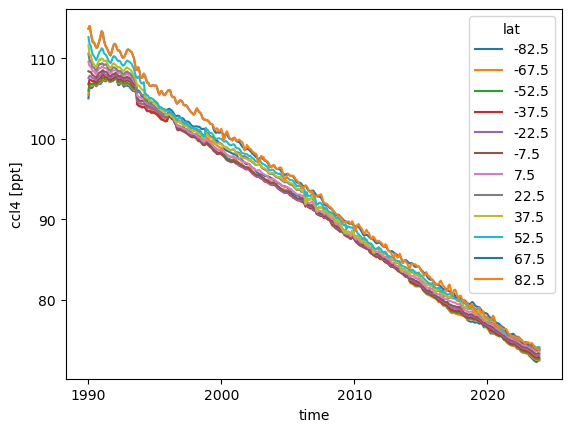

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

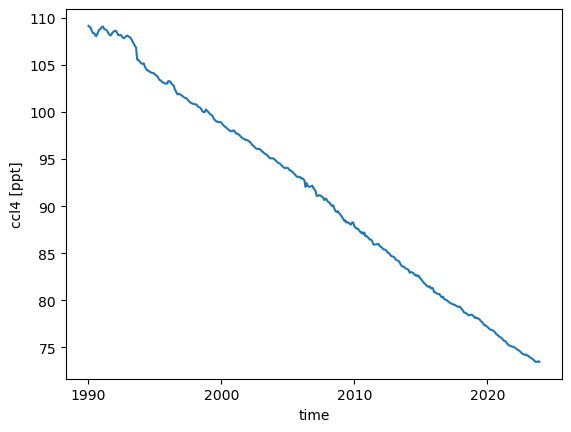

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

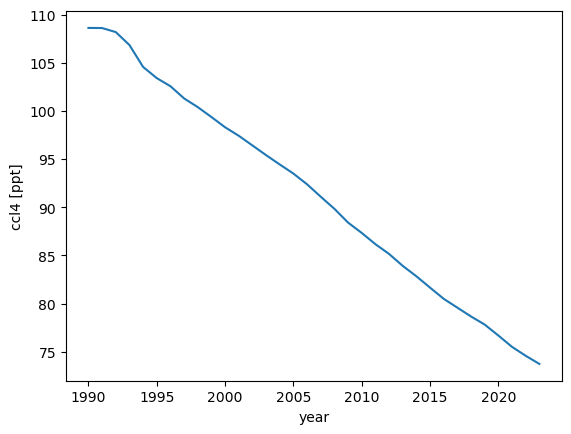

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 5kB
Dimensions:               (lat: 12, eof: 12, year: 34)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 272B 1990 1991 1992 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.1183 ... -0.05329
    principal-components  (year, eof) float64 3kB [] -6.869 -1.492 ... 1.182e-14

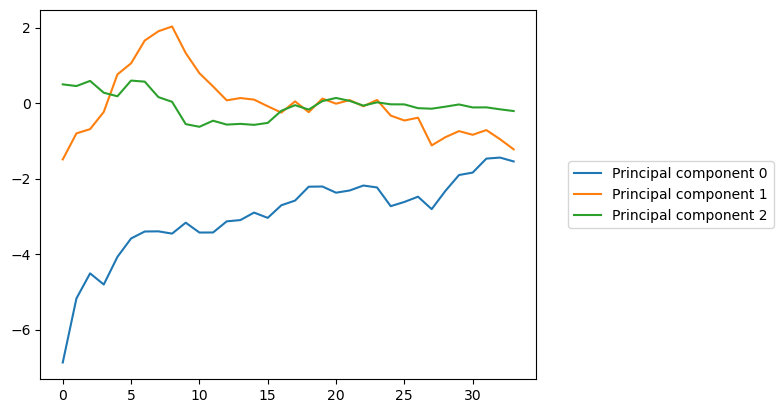

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

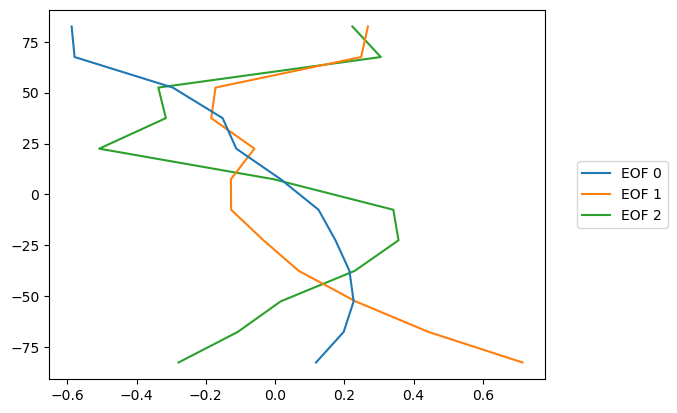

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

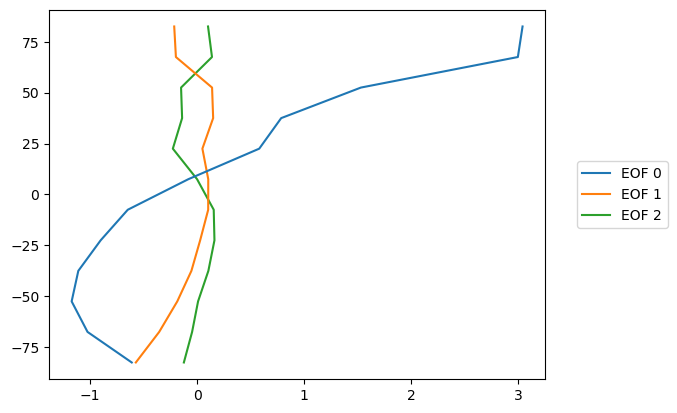

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.11834824716418463] [0.19814725116835052] [0.22686661935044816] [0.21481947603605459] [0.17445092790415073] [0.12553343381999932] [0.01621260467434093] [-0.11186483354084903] [-0.1514957190874856] [-0.2953740653550646] [-0.5788261780442029] [-0.5872908942130007]]
Units,ppt
Magnitude,[[-6.868833348956795] [-5.173438603884148] [-4.5095233551681355] [-4.804932864723086] [-4.072838687093177] [-3.5853954572734716] [-3.4009406588146263] [-3.396896622894892] [-3.4568946512813765] [-3.1676401942873764] [-3.4285698021047626] [-3.4269855080315317] [-3.1324146419760486] [-3.098360675626549] [-2.899978781670954] [-3.040009699046866] [-2.705508345546067] [-2.583011101919827] [-2.2151048173571657] [-2.2097993654239154] [-2.3738428427359013] [-2.314850226009149] [-2.1838880307226907] [-2.2346044240451803] [-2.7305194701355795] [-2.618567273264938] [-2.47995189629802] [-2.8089656983932656] [-2.3273397293886515] [-1.905502941902279] [-1.8412575263675068] [-1.4714827872887297] [-1.4438172852294866] [-1.5462621813097774]]
Units,dimensionless


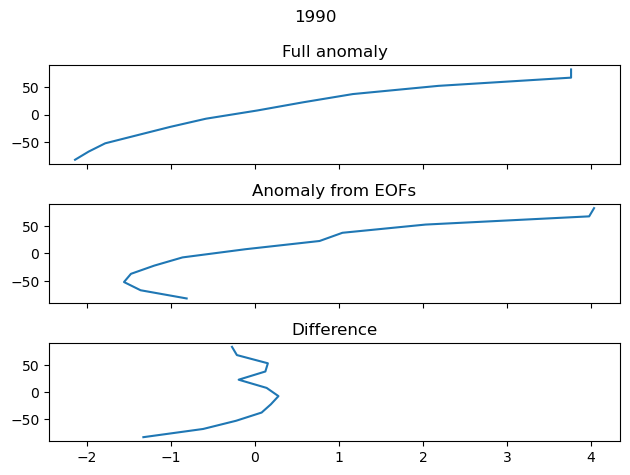

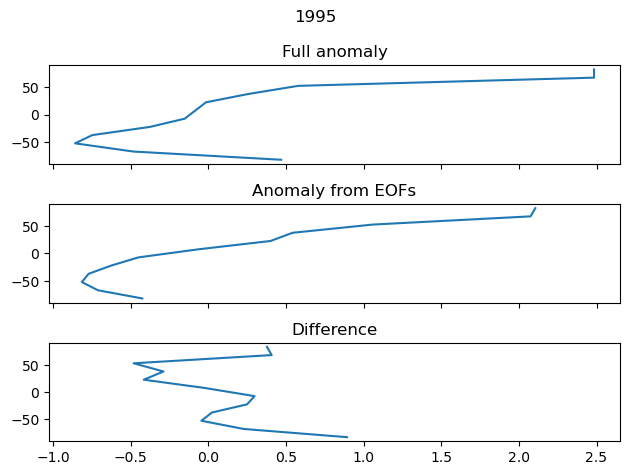

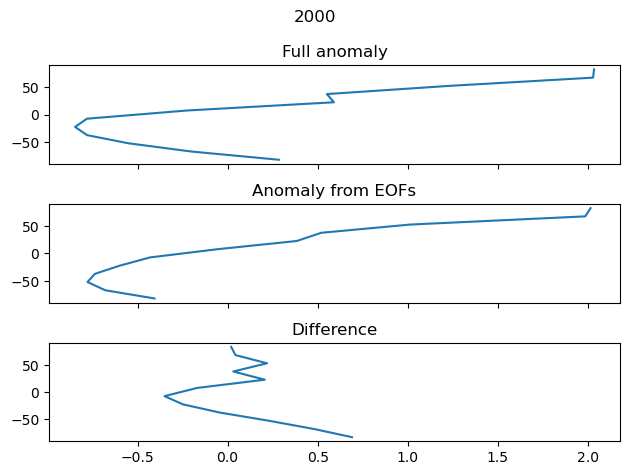

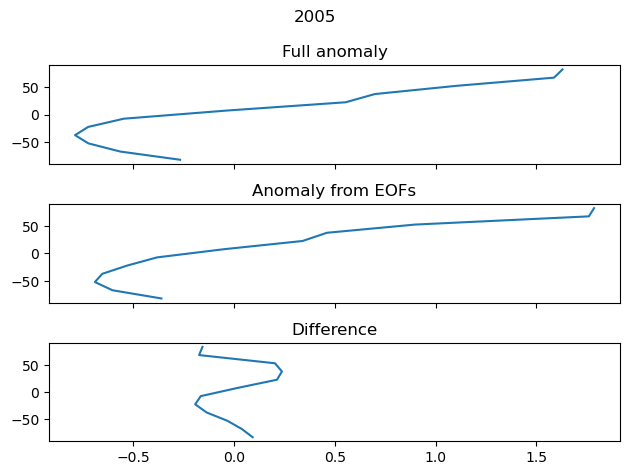

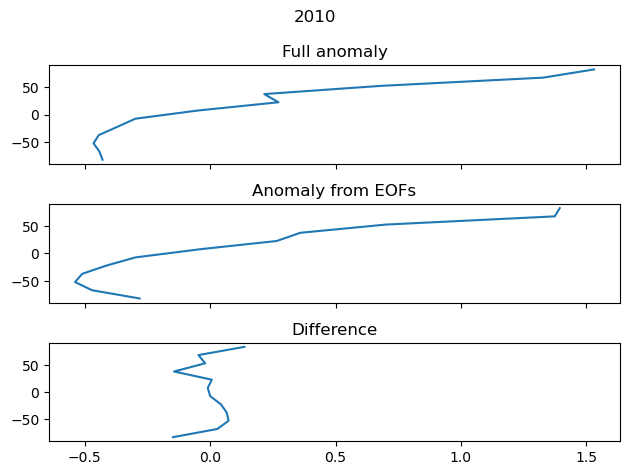

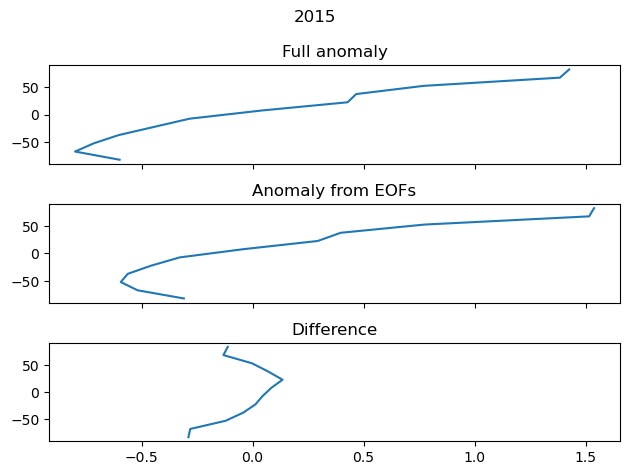

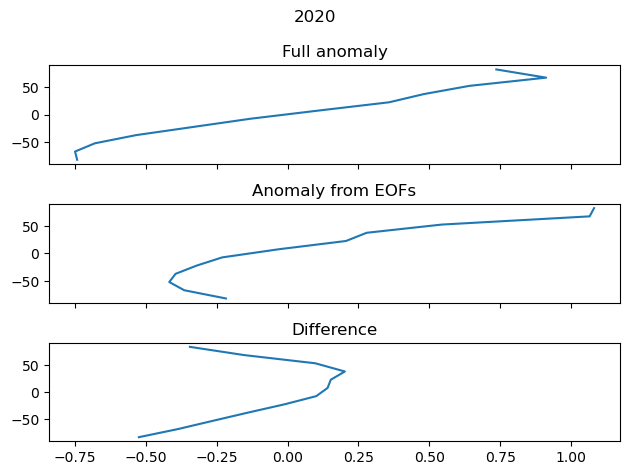

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/408 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 408/408 [00:00<00:00, 16757.83it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/408 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/408 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 408/408 [00:00<00:00, 20506.85it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/408 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 408/408 [00:00<00:00, 21094.31it/s]

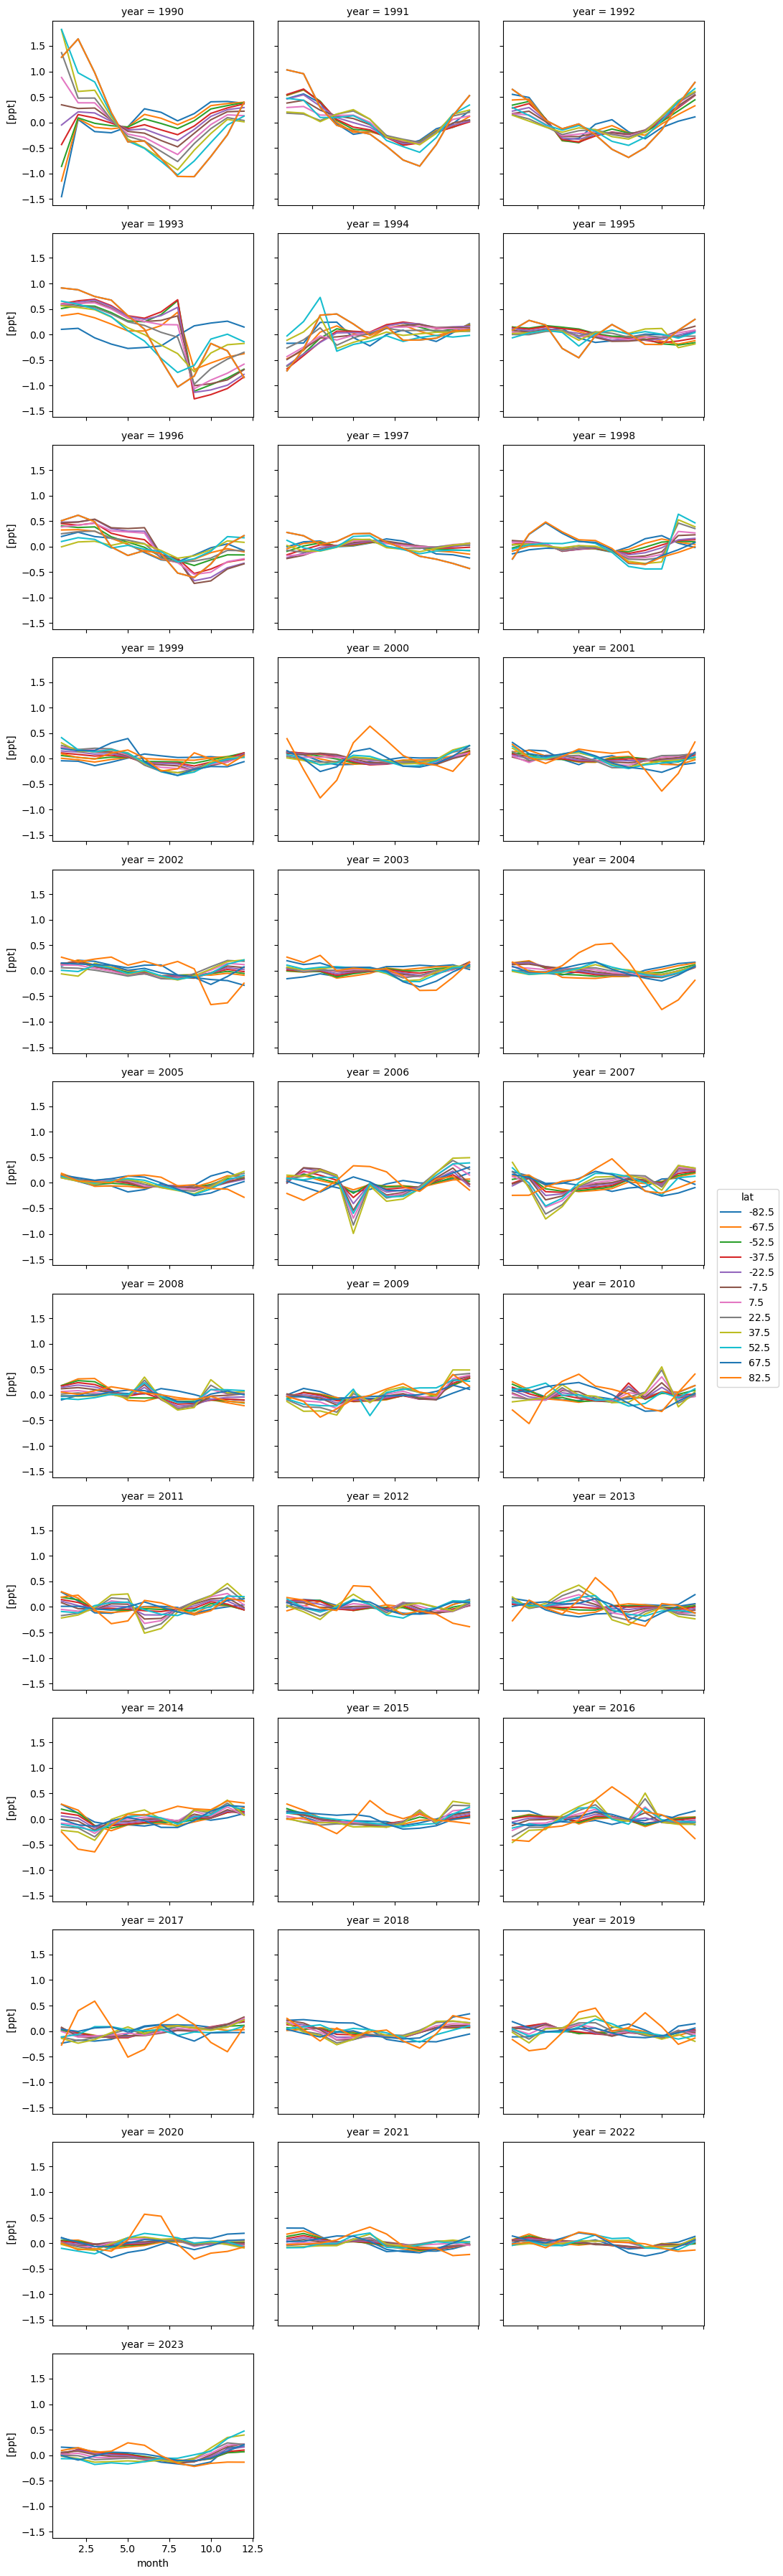

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

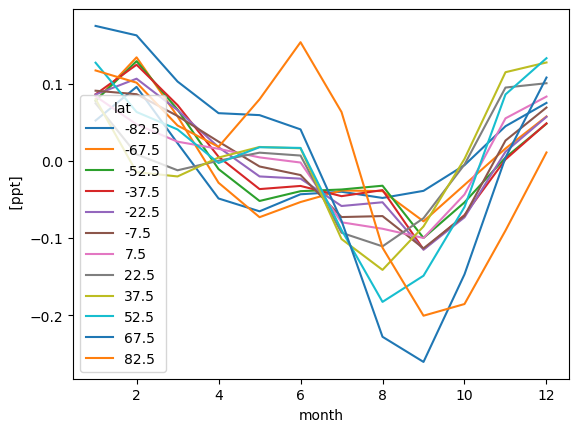

In [22]:
seasonality.plot.line(hue="lat")

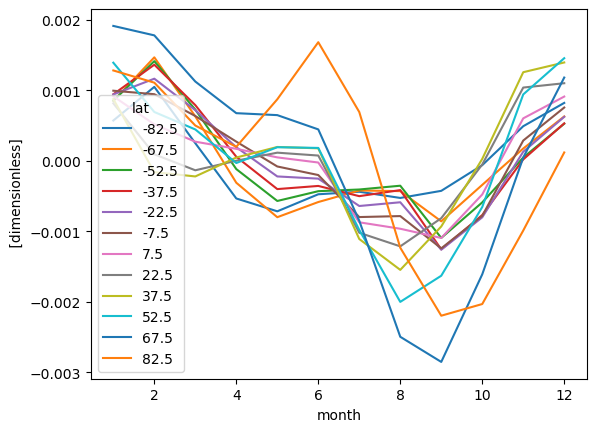

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[108.61295137080417 108.60059060622848 108.18013066785248 106.8361676334943 104.5607144544558 103.4008349474812 102.55966876319245 101.29394389201606 100.38965532085108 99.36181427121407 98.29682788078689 97.41532482896189 96.41058278245949 95.40395785084813 94.43668743867966 93.48859198520972 92.37664132548106 91.08700958553253 89.83240167327689 88.40310996391186 87.32755041568447 86.16240976690047 85.14771175021235 83.90943653761568 82.82761526556932 81.64846170585427 80.48718597741222 79.57015307361755 78.65282789046384 77.81219618580069 76.67539863850382 75.49779358739094 74.57139107083385 73.72792085074738]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.11834824716418463] [0.19814725116835052] [0.22686661935044816] [0.21481947603605459] [0.17445092790415073] [0.12553343381999932] [0.01621260467434093] [-0.11186483354084903] [-0.1514957190874856] [-0.2953740653550646] [-0.5788261780442029] [-0.5872908942130007]]
Units,ppt
Magnitude,[[-6.868833348956795] [-5.173438603884148] [-4.5095233551681355] [-4.804932864723086] [-4.072838687093177] [-3.5853954572734716] [-3.4009406588146263] [-3.396896622894892] [-3.4568946512813765] [-3.1676401942873764] [-3.4285698021047626] [-3.4269855080315317] [-3.1324146419760486] [-3.098360675626549] [-2.899978781670954] [-3.040009699046866] [-2.705508345546067] [-2.583011101919827] [-2.2151048173571657] [-2.2097993654239154] [-2.3738428427359013] [-2.314850226009149] [-2.1838880307226907] [-2.2346044240451803] [-2.7305194701355795] [-2.618567273264938] [-2.47995189629802] [-2.8089656983932656] [-2.3273397293886515] [-1.905502941902279] [-1.8412575263675068] [-1.4714827872887297] [-1.4438172852294866] [-1.5462621813097774]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.0005708070934534974 0.001048201401646728 0.00024932894231364725 -0.0005345011639988647 -0.0007164433402105138 -0.0004747699361399817 -0.00043901922711917185 -0.0005269245114321855 -0.0004261885420723251 -6.167675120549773e-05 0.0004902385088322905 0.0008209505460707514] [0.0008480244672118956 0.001467004068152821 0.0006295542683025364 -0.00031150190691446274 -0.0007998761239527932 -0.0005848841816478317 -0.0004208052379702983 -0.00043014901949550656 -0.0008584962565748248 -0.0003416362581369122 0.0001739795600211215 0.0006287896760366815] [0.0008523450995487307 0.001412725845720275 0.0007262265418386555 -0.00011783722326985541 -0.0005698620839990087 -0.0004310581080213306 -0.00040715477550619644 -0.00035350386890200115 -0.0010939415459258017 -0.0005899060220171824 4.630469523666699e-05 0.0005256645240539792] [0.0009427280795819117 0.0013624766736091028 0.0007893581102959735 5.708907781468324e-05 -0.0004013039550629081 -0.00035663102876009705 -0.0005016865578823576 -0.000415586072897041 -0.001256218946186622 -0.0007699372508463773 1.916184043996001e-05 0.0005305533454880029] [0.0009404540712219678 0.0011641503501137664 0.0007179251929358824 0.0001926278580524601 -0.00022192968953957433 -0.00025314660033181154 -0.0006411648262526444 -0.0005881910738456008 -0.0012607220148980127 -0.000801783497465386 0.00012856234335083922 0.0006232215206168477] [0.0009938333012958704 0.0009441797144350221 0.0006353097309230336 0.00027155551826414567 -8.061190303085146e-05 -0.00020219374353166084 -0.0007979593910802094 -0.00078417192264828 -0.0012416127127614402 -0.000780461584789581 0.0002869250613830111 0.000755211882449396] [0.0009149719660401685 0.0005164217711361976 0.0002709852929491769 0.00016967284598653421 4.8239982989181755e-05 -2.4697348938159184e-05 -0.0008722843741472364 -0.0009637325472087313 -0.001094628785944595 -0.0004775964050064668 0.000601807026410564 0.0009108443851145692] [0.0008148555585549227 9.218041183008852e-05 -0.00013467781170592056 7.10405624539911e-07 0.00011512277927281007 7.433360826520983e-05 -0.0010206994938826138 -0.0012133291748650723 -0.0008141907155710752 -5.272503976407175e-05 0.0010384187895582952 0.0011000042046011844] [0.0008748447326625267 -0.00016132102105811082 -0.00022193066702149962 4.601590000801869e-05 0.00019605262975731896 0.0001767662030232693 -0.0011094145100109904 -0.001546990681552224 -0.0009314483365319724 2.6840818349055428e-05 0.001256234941983667 0.0013943546059094606] [0.0013909133436687759 0.0006921160592695556 0.00044439316283911905 -3.165791758680853e-05 0.0001925192340160131 0.00018242976302417386 -0.0009804356016606573 -0.00200095329122709 -0.0016300606554228844 -0.0006553074805842017 0.0009411849855278286 0.0014548640051176842] [0.001912549940810091 0.0017785451238505597 0.0011238998216826076 0.0006752302801597593 0.0006475704929824683 0.0004451388280025352 -0.0008505677871396639 -0.002495844229115474 -0.002852282635969528 -0.0016100775629346977 4.5365638421304825e-05 0.001180476700639748] [0.0012810913402975187 0.0011078469842142695 0.0004999686411095587 0.00019793184989753517 0.0008719939402211684 0.001681614575907184 0.000691510302695749 -0.0012327768250288238 -0.0021968979406765477 -0.002031368274019894 -0.000989067986734537 0.000118156387395913]]
Units,dimensionless
